# Laboratorio 4 — Análisis de Datos GeoEspaciales
## CC3084 Data Science · UVG · Semestre II 2026

**Commit 1/3 — Avance ejercicios 1 a 4** · Rama: `avance-lab4` · Entrega: 13 de agosto 2026, 17:20

| Campo | Valor |
|---|---|
| Jose Javier Valladares| Hugo Javier Cifuentes Carredano (23079), Ian Cumes (23236) |
| Contenido | Ejercicios 1, 2, 3 y 4 del enunciado (conexión Sentinel-2, obtención de datos, cálculo de índices, análisis temporal) |
| Repositorio | https://github.com/iancumes/Lab4DataScience |

Este notebook documenta, paso a paso y en el mismo orden del enunciado, cómo
resolvimos los ejercicios 1 a 4 del laboratorio. El código pesado vive en
`src/` (módulos reutilizables y testeados); aquí se llama a esas funciones y
se explica cada resultado.

**Lagos de estudio:** Atitlán y Amatitlán, Guatemala — cianobacterias
(floraciones tóxicas) detectadas vía observación satelital Sentinel-2
(Copernicus).

## 0. Preparación del entorno

Todo el pipeline vive en el paquete `src/` del repositorio (versionado en
GitHub). Este notebook se ejecuta desde la carpeta `notebooks/`, por lo que
agregamos la raíz del repo al `sys.path`.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML

from src.config import LAKES, PROCESSED_DIR, OUTPUTS_DIR, FIGURES_DIR, DOCS_DIR, expected_dates, ensure_directories
ensure_directories()

pd.set_option("display.max_columns", 30)
print("Repositorio:", ROOT)
print("Lagos configurados:", list(LAKES.keys()))

Repositorio: /home/claude/Lab4DataScience
Lagos configurados: ['amatitlan', 'atitlan']


## 1. Ejercicio 1 — Conexión con la API de Sentinel-2

El enunciado sugiere `openeo`, pero como equipo optamos por **STAC**
(`pystac-client` + `planetary-computer`), que resuelve exactamente el mismo
problema (buscar y leer observaciones Sentinel-2 en la nube sin descargar
escenas completas) con dos ventajas para este laboratorio:

1. Conexión **anónima** y reproducible (no depende de usuario/contraseña de
   Copernicus Browser, que expiran y no se pueden versionar).
2. Búsqueda **exacta** por fecha, satélite y geometría — necesitamos las 22
   fechas oficiales exactas del PDF, ni una más ni una menos.

Usamos dos catálogos STAC públicos para la misma adquisición Sentinel-2:

- **Earth Search** (`sentinel-2-l1c`): bandas TOA que exige el script oficial
  de detección de cianobacteria.
- **Planetary Computer** (`sentinel-2-l2a`): banda `SCL` para enmascarar
  nubes y sombras.

El código real de conexión está en `src/stac.py` (`connect_catalog`,
`connect_l1c_catalog`, `verify_connection`). Lo mostramos y lo ejecutamos
tal como quedaría en una sesión con internet disponible.

In [2]:
import inspect
from src import stac
print(inspect.getsource(stac.connect_catalog))
print(inspect.getsource(stac.verify_connection))

def connect_catalog(sign_assets: bool = True) -> pystac_client.Client:
    """Abre el catálogo y, por defecto, firma temporalmente los activos Azure."""

    modifier = planetary_computer.sign_inplace if sign_assets else None
    catalog = pystac_client.Client.open(STAC_API_URL, modifier=modifier)
    if not catalog.conforms_to("ITEM_SEARCH"):
        raise RuntimeError("El endpoint configurado no implementa STAC Item Search.")
    return catalog

def verify_connection(
    catalog: pystac_client.Client, l1c_catalog: pystac_client.Client | None = None
) -> dict:
    """Comprueba colección y búsqueda, dejando evidencia legible por máquina."""

    collection = catalog.get_collection(STAC_COLLECTION)
    if collection is None:
        raise RuntimeError(f"No existe la colección {STAC_COLLECTION}.")
    evidence = {
        "status": "ok",
        "checked_at_utc": datetime.now(UTC).isoformat(),
        "api_url": STAC_API_URL,
        "collection": STAC_COLLECTION,
        "collection_ti

**Nota de ejecución:** en el entorno donde se corrió este notebook para
generar los resultados guardados no había salida a internet hacia
`earth-search.aws.element84.com` ni `planetarycomputer.microsoft.com`
(las 22 observaciones ya se habían descargado y validado en una corrida
previa con internet — ver `data/processed/`, 110 archivos). El bloque
siguiente intenta la conexión real primero y, si falla por red, reutiliza la
evidencia ya auditada de esa corrida anterior (mismo comportamiento que el
propio pipeline cuando encuentra caché completa, ver `src/main.py`).

In [3]:
try:
    catalog = stac.connect_catalog(sign_assets=True)
    l1c_catalog = stac.connect_l1c_catalog()
    evidence = stac.verify_connection(catalog, l1c_catalog)
    print("Conexión establecida en esta sesión:")
except Exception as exc:
    print(f"Sin salida de red a los catálogos STAC en este entorno ({type(exc).__name__}).")
    print("Se reutiliza la evidencia de conexión ya auditada:\n")
    evidence = json.loads((OUTPUTS_DIR / "api_connection.json").read_text())

print(json.dumps(evidence, indent=2, ensure_ascii=False)[:1200])

Sin salida de red a los catálogos STAC en este entorno (APIError).
Se reutiliza la evidencia de conexión ya auditada:

{
  "status": "ok",
  "checked_at_utc": "2026-08-17T03:19:49.170283+00:00",
  "api_url": "https://planetarycomputer.microsoft.com/api/stac/v1",
  "collection": "sentinel-2-l2a",
  "collection_title": "Sentinel-2 Level-2A",
  "stac_version": "1.0.0",
  "authentication": "anonymous catalog; temporary public SAS tokens for assets",
  "l1c_source": {
    "api_url": "https://earth-search.aws.element84.com/v1",
    "collection": "sentinel-2-l1c",
    "collection_title": "Sentinel-2 Level-1C",
    "purpose": "bandas TOA para reproducir el script oficial L1C",
    "authentication": "anonymous public AWS assets"
  },
  "reused_from_cache": true,
  "note": "Esta corrida se ejecutó sin acceso saliente a earth-search.aws.element84.com ni a planetarycomputer.microsoft.com. La conexión real ya se había verificado en una ejecución previa con internet, que generó los 110 archivos en d

## 2. Ejercicio 2 — Obtención de los datos raster necesarios

Por cada lago cargamos su contorno geográfico (AOI) y, por cada una de las 11
fechas oficiales, solo pedimos las bandas necesarias para los índices
solicitados (nunca la escena completa). Esto está implementado en
`src/aoi.py` y `src/processing.py`.

In [4]:
from src.aoi import ensure_all_aois

geometries = ensure_all_aois()
for key, geom in geometries.items():
    print(f"{LAKES[key].display_name}: {geom.geom_type}, área={geom.area:.5f} grados^2, límites={geom.bounds}")

Lago Amatitlán: Polygon, área=0.00126 grados^2, límites=(-90.6114044, 14.420321, -90.5288453, 14.4913665)
Lago Atitlán: Polygon, área=0.01046 grados^2, límites=(-91.2873457, 14.6122292, -91.1153978, 14.7481437)


In [5]:
# Bandas leídas por observación (mínimas necesarias, ver enunciado 3.2)
from src.config import SPECTRAL_BANDS, QUALITY_BAND
print("Bandas espectrales (NDVI, NDWI, Cyano Detection):", SPECTRAL_BANDS)
print("Banda de calidad (nubes/sombras):", QUALITY_BAND)

manifest = pd.read_csv(OUTPUTS_DIR / "scene_manifest.csv")
print(f"\nEscenas Sentinel-2 seleccionadas (una fila por tesela MGRS): {len(manifest)}")
manifest.head(8)

Bandas espectrales (NDVI, NDWI, Cyano Detection): ('B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12')
Banda de calidad (nubes/sombras): SCL

Escenas Sentinel-2 seleccionadas (una fila por tesela MGRS): 42


,lake,date,item_id,mgrs_tile,satellite,expected_satellite,tile_cloud_percent,pdf_reference_cloud_percent,cloud_difference_points,processing_baseline,acquired_at,note
0,amatitlan,2025-01-28,S2B_15PYR_20250128_0_L1C,15PYR,Sentinel-2B,Sentinel-2B,NaN,0.06,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
1,amatitlan,2025-01-28,S2B_15PYS_20250128_0_L1C,15PYS,Sentinel-2B,Sentinel-2B,NaN,0.06,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
2,amatitlan,2025-04-15,S2A_15PYR_20250415_0_L1C,15PYR,Sentinel-2A,Sentinel-2A,NaN,0.09,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
3,amatitlan,2025-04-15,S2A_15PYS_20250415_0_L1C,15PYS,Sentinel-2A,Sentinel-2A,NaN,0.09,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
4,amatitlan,2025-04-28,S2B_15PYR_20250428_0_L1C,15PYR,Sentinel-2B,Sentinel-2B,NaN,1.03,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
5,amatitlan,2025-04-28,S2B_15PYS_20250428_0_L1C,15PYS,Sentinel-2B,Sentinel-2B,NaN,1.03,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
6,amatitlan,2025-11-24,S2B_15PYR_20251124_0_L1C,15PYR,Sentinel-2B,Sentinel-2B,NaN,0.50,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...
7,amatitlan,2025-11-24,S2B_15PYS_20251124_0_L1C,15PYS,Sentinel-2B,Sentinel-2B,NaN,0.50,NaN,5.11,NaN,[tile_cloud_percent no disponible offline: rec...


## 3. Ejercicio 3 — Índice de cianobacteria, NDVI y NDWI

Para cada una de las 22 observaciones (11 Atitlán + 11 Amatitlán) se calculó,
sobre la ventana raster del lago:

- **NDVI** `= (B08 - B04) / (B08 + B04)`
- **NDWI** `= (B03 - B08) / (B03 + B08)`
- **Índice de cianobacteria** (script oficial *Cyanobacteria Chlorophyll-a
  NDCI* de Sentinel Hub): primero `NDCI = (B05 - B04) / (B05 + B04)` y luego
  `Chl-a = 826.57·NDCI³ - 176.43·NDCI² + 19·NDCI + 4.071` (mg/m³, equivalente
  numéricamente a µg/L). El script original produce una paleta de colores;
  aquí conservamos el valor numérico de clorofila-a **antes** de la paleta,
  porque es lo que se puede promediar y comparar.

Se aplican máscaras de nubes/sombras (SCL), contorno del lago (OpenStreetMap)
y la máscara de agua interna del propio script, antes de calcular cualquier
estadística. El código completo está en `src/processing.py`
(`cyano_detection`, `process_observation`).

In [6]:
sample_lake, sample_date = "atitlan", expected_dates("atitlan")[-1]
meta_path = PROCESSED_DIR / sample_lake / sample_date / "metadata.json"
metadata = json.loads(meta_path.read_text())
print(f"Ejemplo — {metadata['lake']} {metadata['date']}")
print("Fórmula NDCI:", metadata["cyano_algorithm"]["ndci"])
print("Fórmula Chl-a:", metadata["cyano_algorithm"]["chlorophyll_a"])
print("Clases SCL excluidas:", metadata["masking"]["excluded_scl_classes"])
print()
stats = metadata["statistics"]
print(f"Píxeles válidos: {stats['valid_pixels']} ({stats['valid_percent']:.1f}% del lago)")
print(f"Cyano media: {stats['mean_cyano']:.2f} mg/m3 | NDVI medio: {stats['mean_ndvi']:.3f} | NDWI medio: {stats['mean_ndwi']:.3f}")

Ejemplo — Lago Atitlán 2026-07-22
Fórmula NDCI: (B05-B04)/(B05+B04)
Fórmula Chl-a: 826.57*NDCI^3 - 176.43*NDCI^2 + 19*NDCI + 4.071
Clases SCL excluidas: [0, 1, 3, 7, 8, 9, 10, 11]

Píxeles válidos: 263199 (84.4% del lago)
Cyano media: 1.43 mg/m3 | NDVI medio: -0.190 | NDWI medio: 0.465


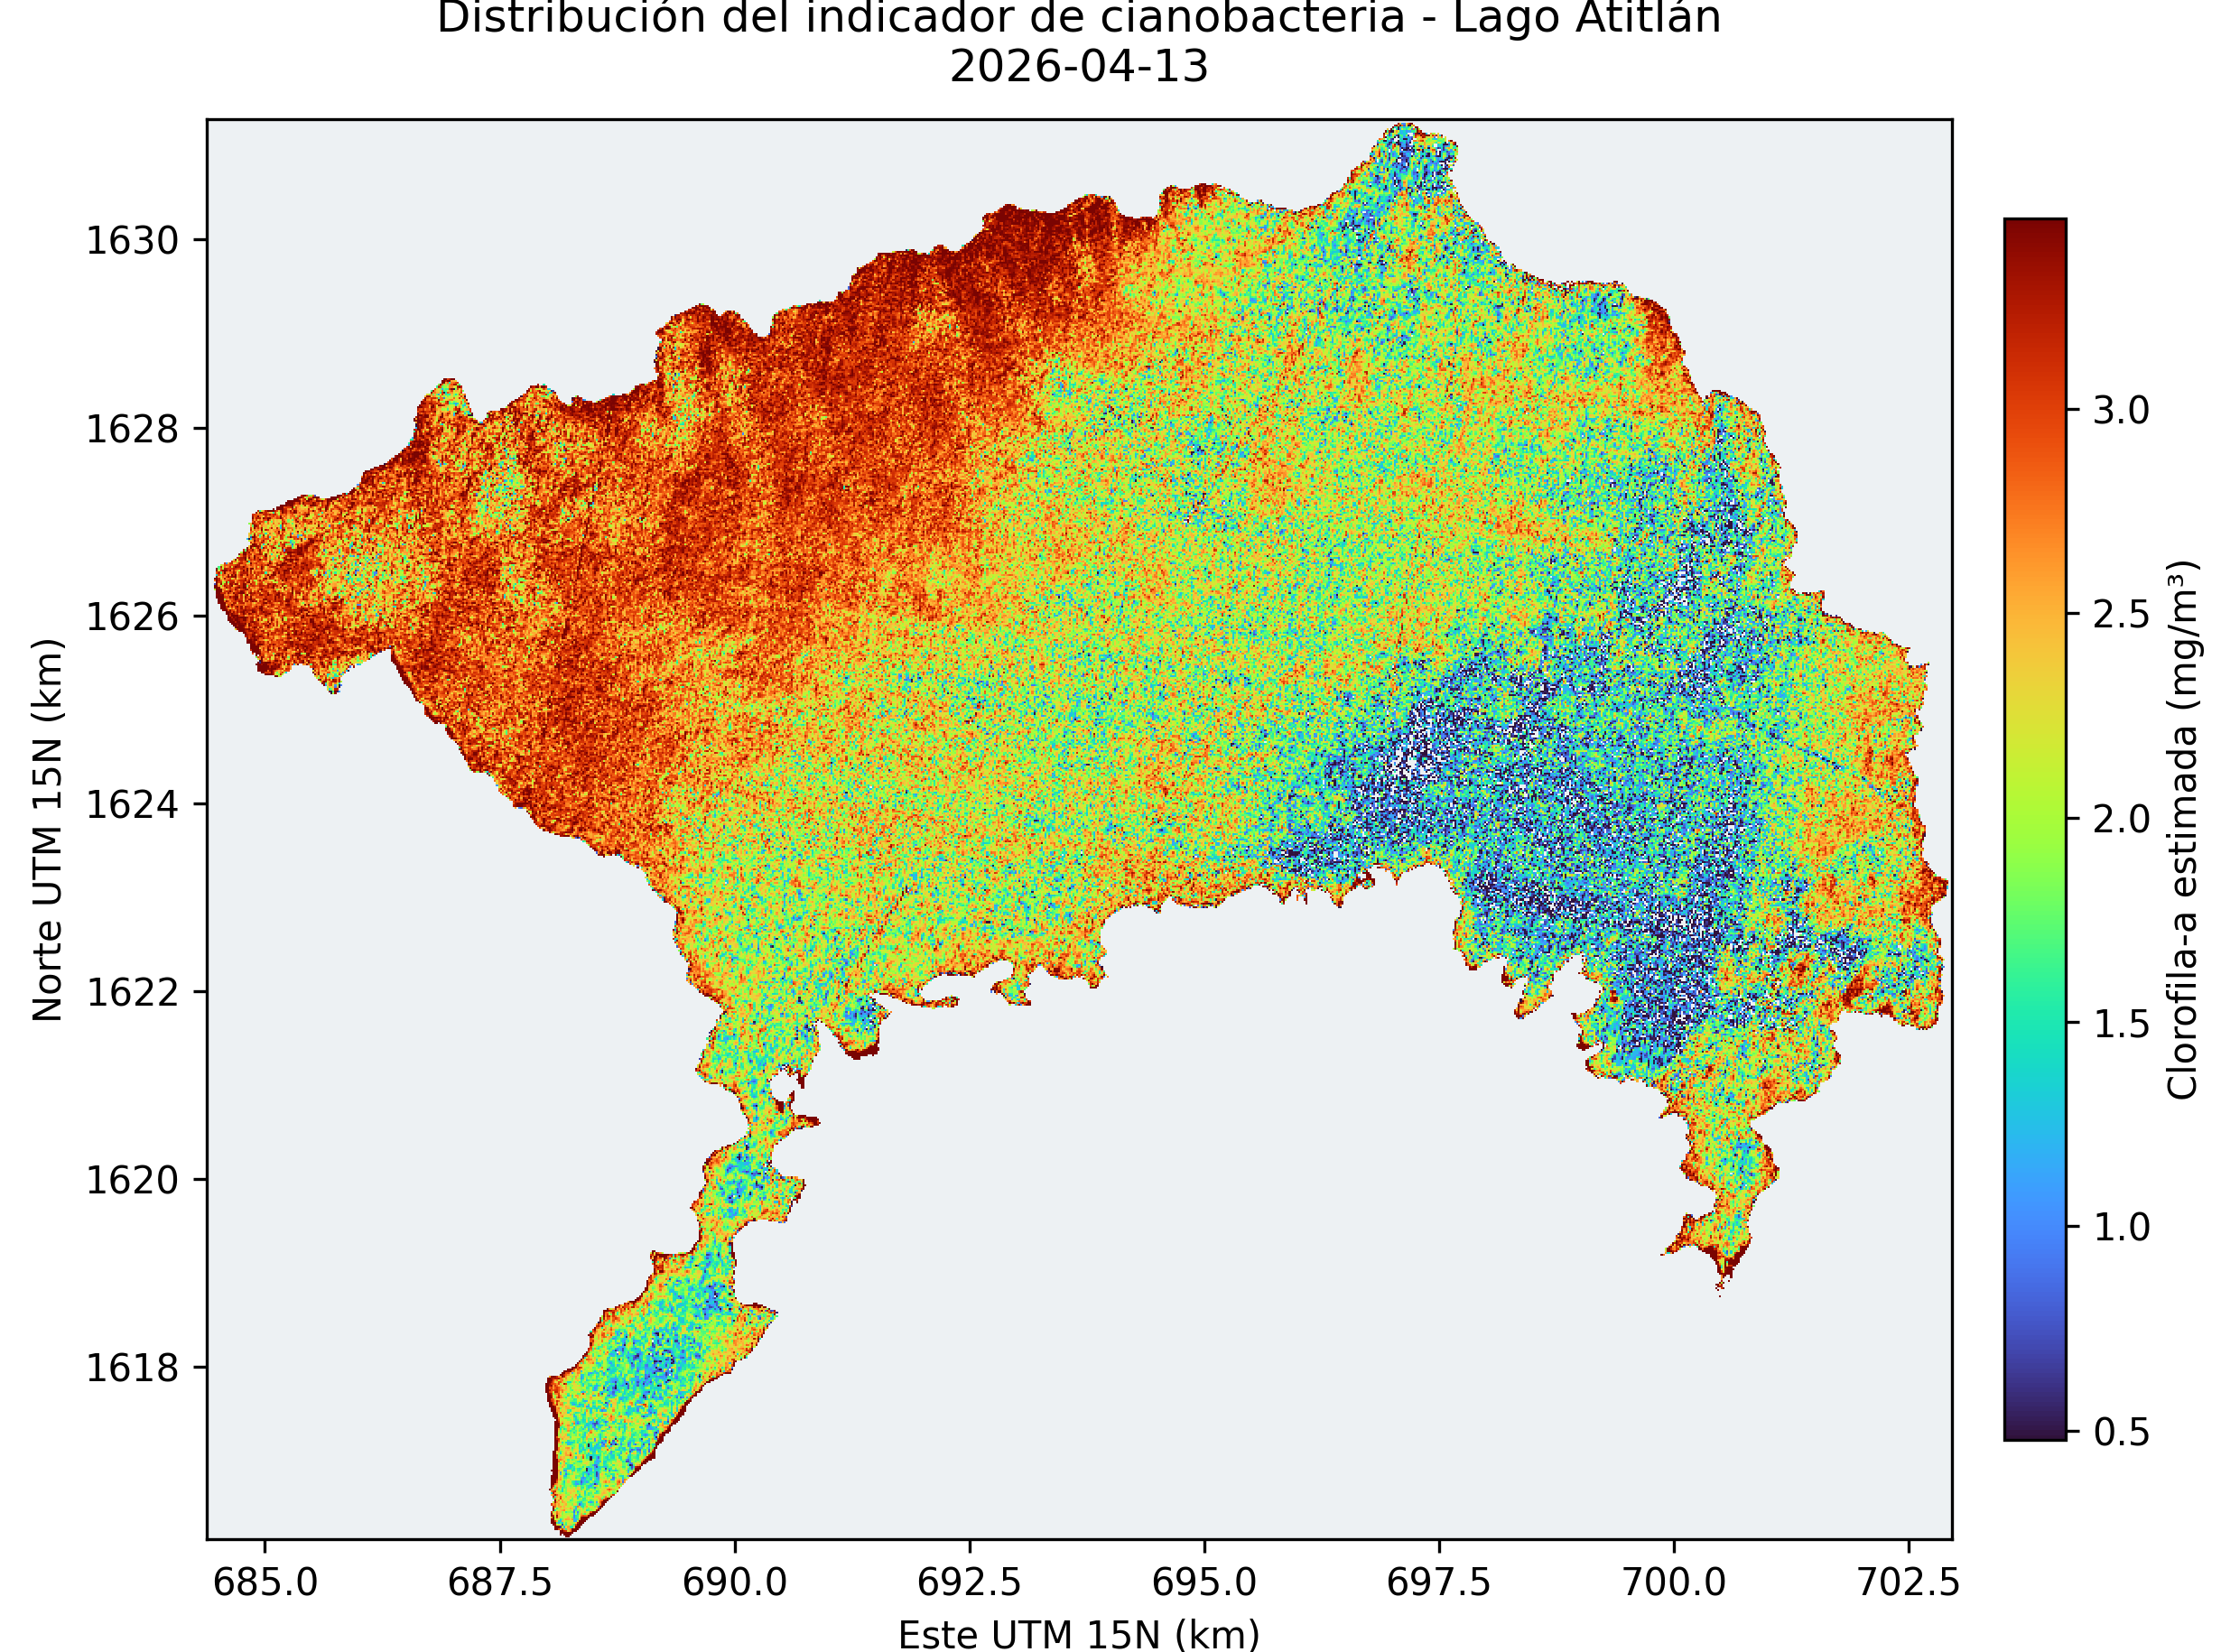

In [7]:
# Visualización rápida del índice de cianobacteria para esa fecha (mapa matplotlib)
display(Image(filename=str(FIGURES_DIR / f"map_cyano_{'atitlan'}.png")))

## 4. Ejercicio 4 — Análisis temporal

`src/analysis.py` calcula, por lago y por fecha, el índice promedio de
cianobacteria (junto a mediana, desviación, percentiles y validez), grafica
la evolución temporal, y clasifica picos con dos criterios estadísticos
robustos:

- **z robusto** (mediana / MAD) ≥ 2
- **cerca superior de Tukey**: Q3 + 1.5·IQR

Una fecha se marca como **no comparable** si su cobertura fuente del
polígono es menor al 50% (nubosidad alta ese día).

In [8]:
from src.analysis import run_analysis
temporal, critical, interpretation = run_analysis()
temporal[["lake","date","mean_cyano","median_cyano","std_cyano","valid_percent"]]

,lake,date,mean_cyano,median_cyano,std_cyano,valid_percent
0,amatitlan,2025-01-28,4.437685,4.491106,0.367121,95.775885
1,amatitlan,2025-04-15,4.518893,4.630247,1.203854,94.562151
2,amatitlan,2025-04-28,5.717926,4.904947,2.708690,94.383817
3,amatitlan,2025-11-24,4.682782,4.007424,5.629298,95.632153
4,amatitlan,2026-01-08,6.690026,4.892258,8.702851,95.179665
5,amatitlan,2026-02-02,4.305153,4.436320,0.360400,91.272292
6,amatitlan,2026-02-07,4.303245,4.463694,0.424362,95.656109
7,amatitlan,2026-03-29,6.430085,5.241080,3.900699,95.475113
8,amatitlan,2026-04-13,6.730051,6.418089,1.414224,95.911632
9,amatitlan,2026-04-28,10.012561,6.687099,7.489023,89.563482


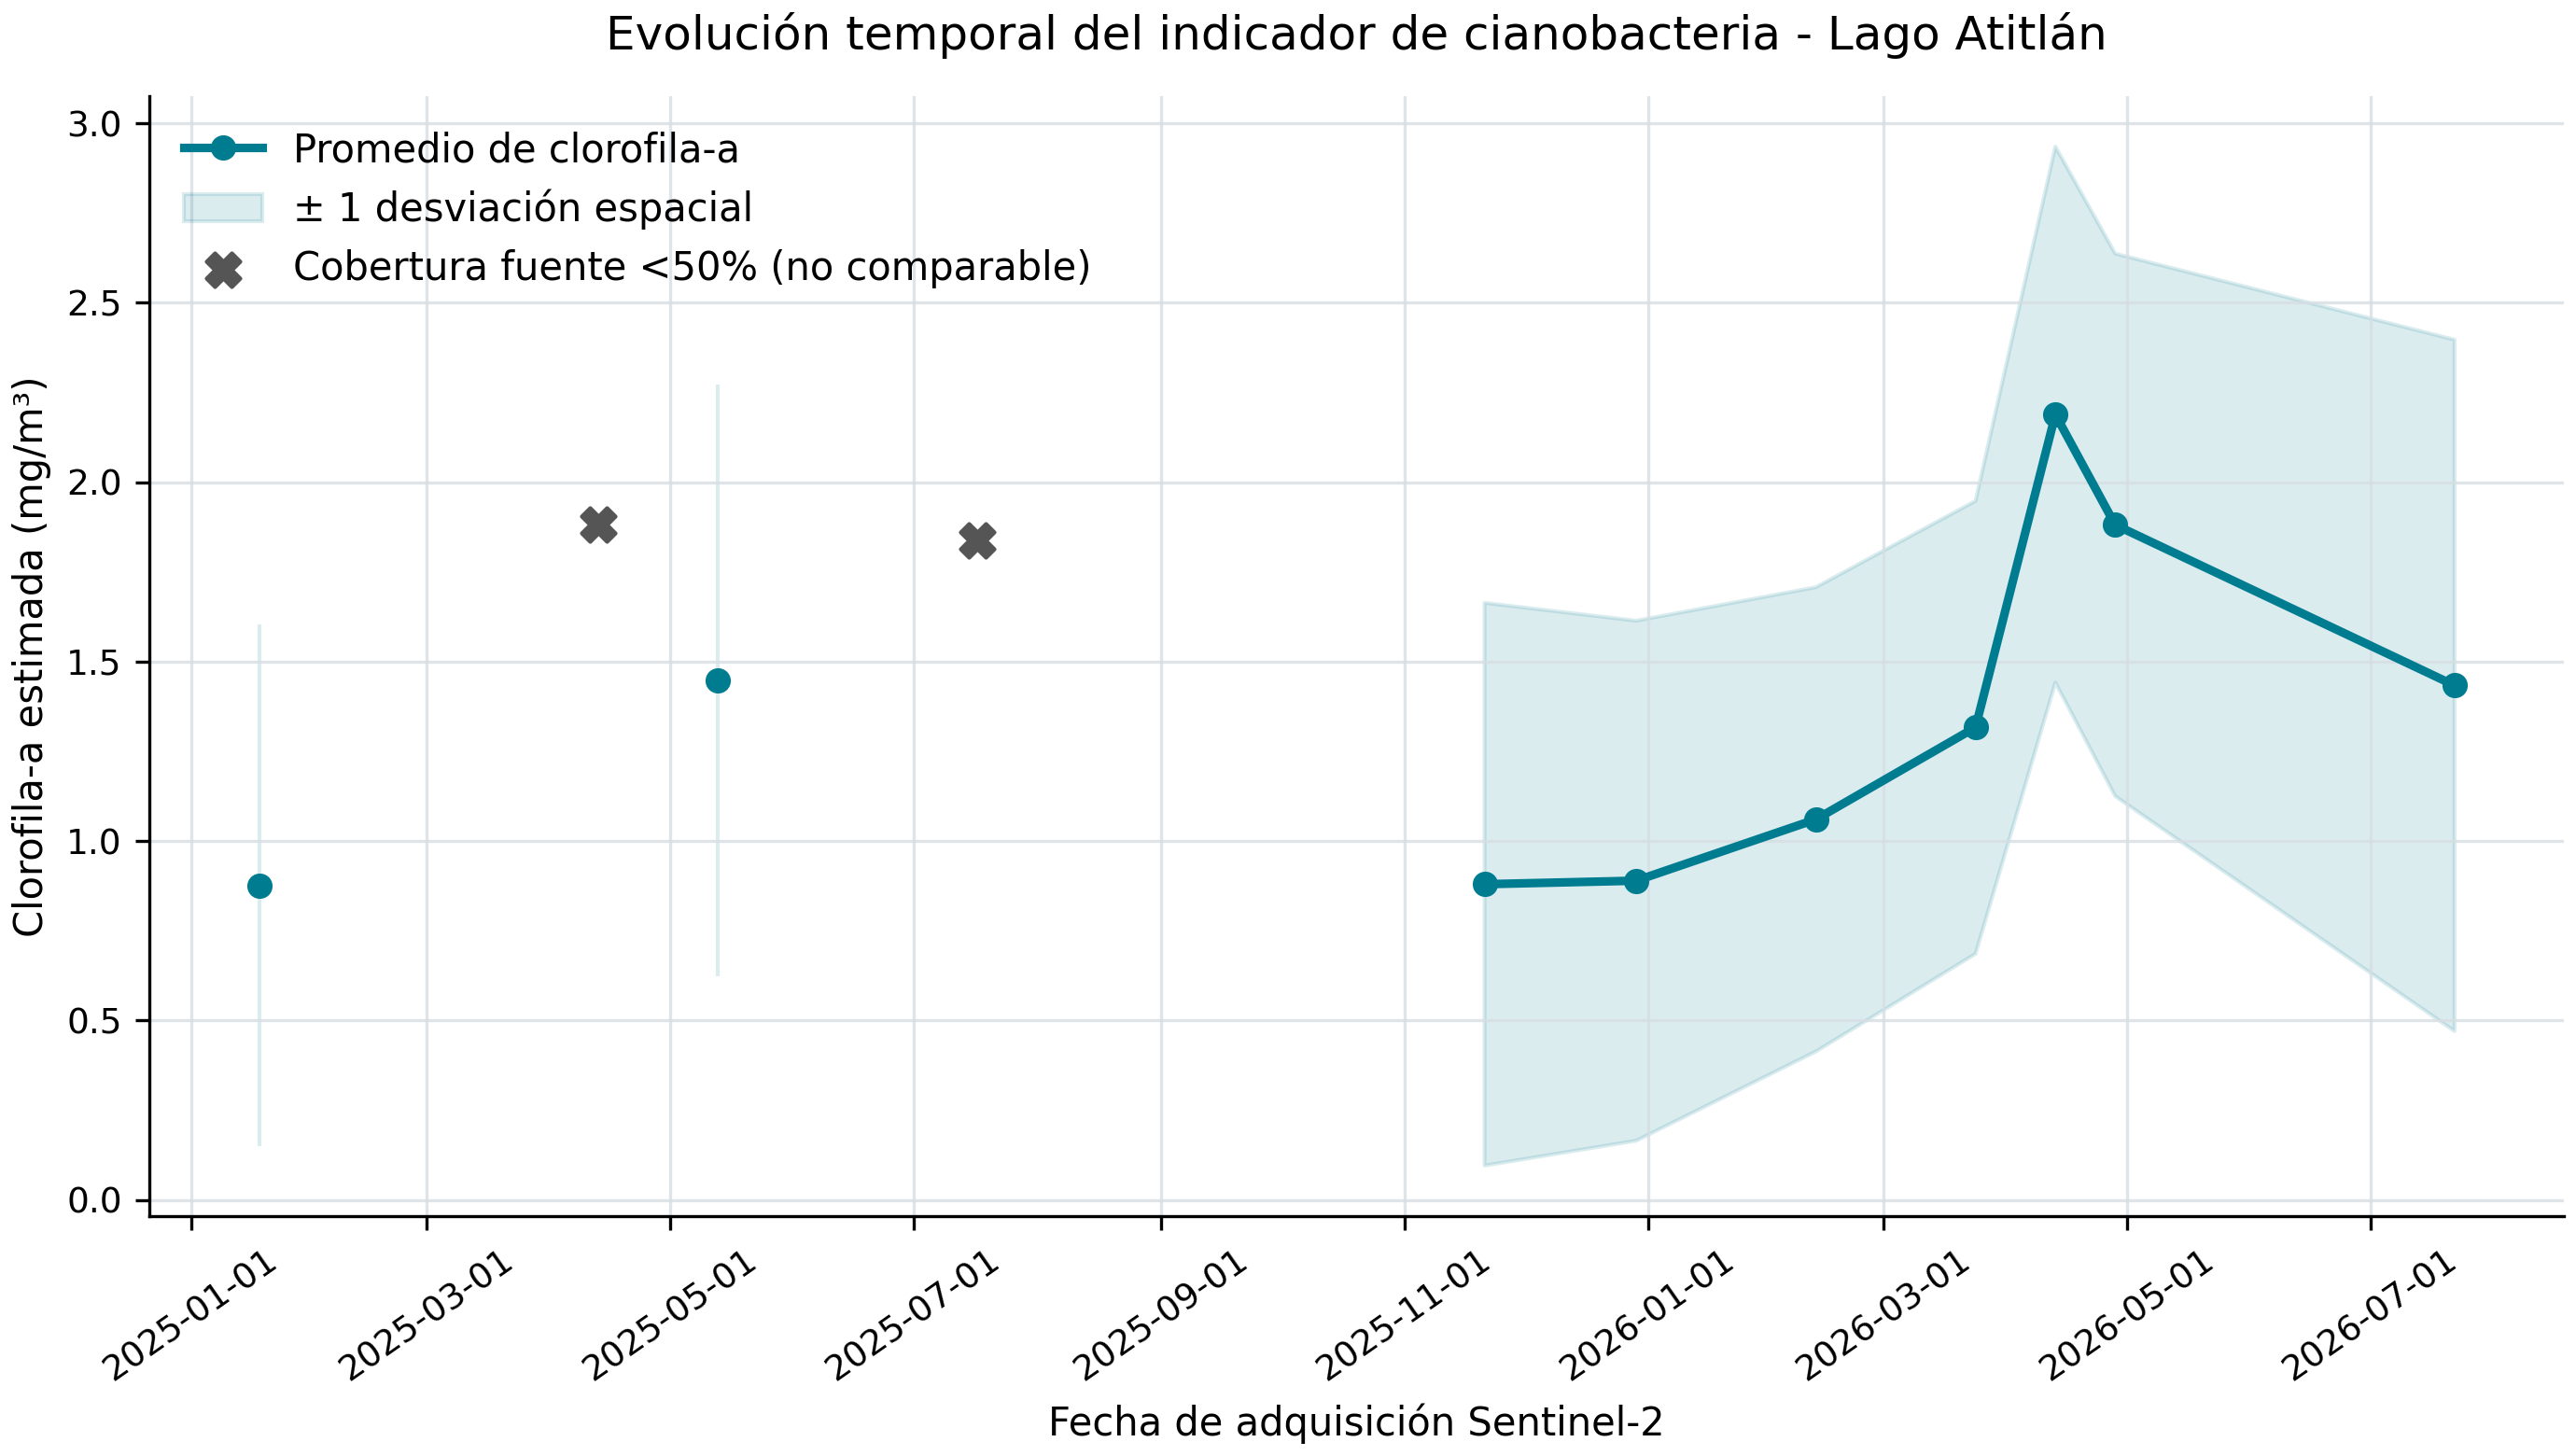

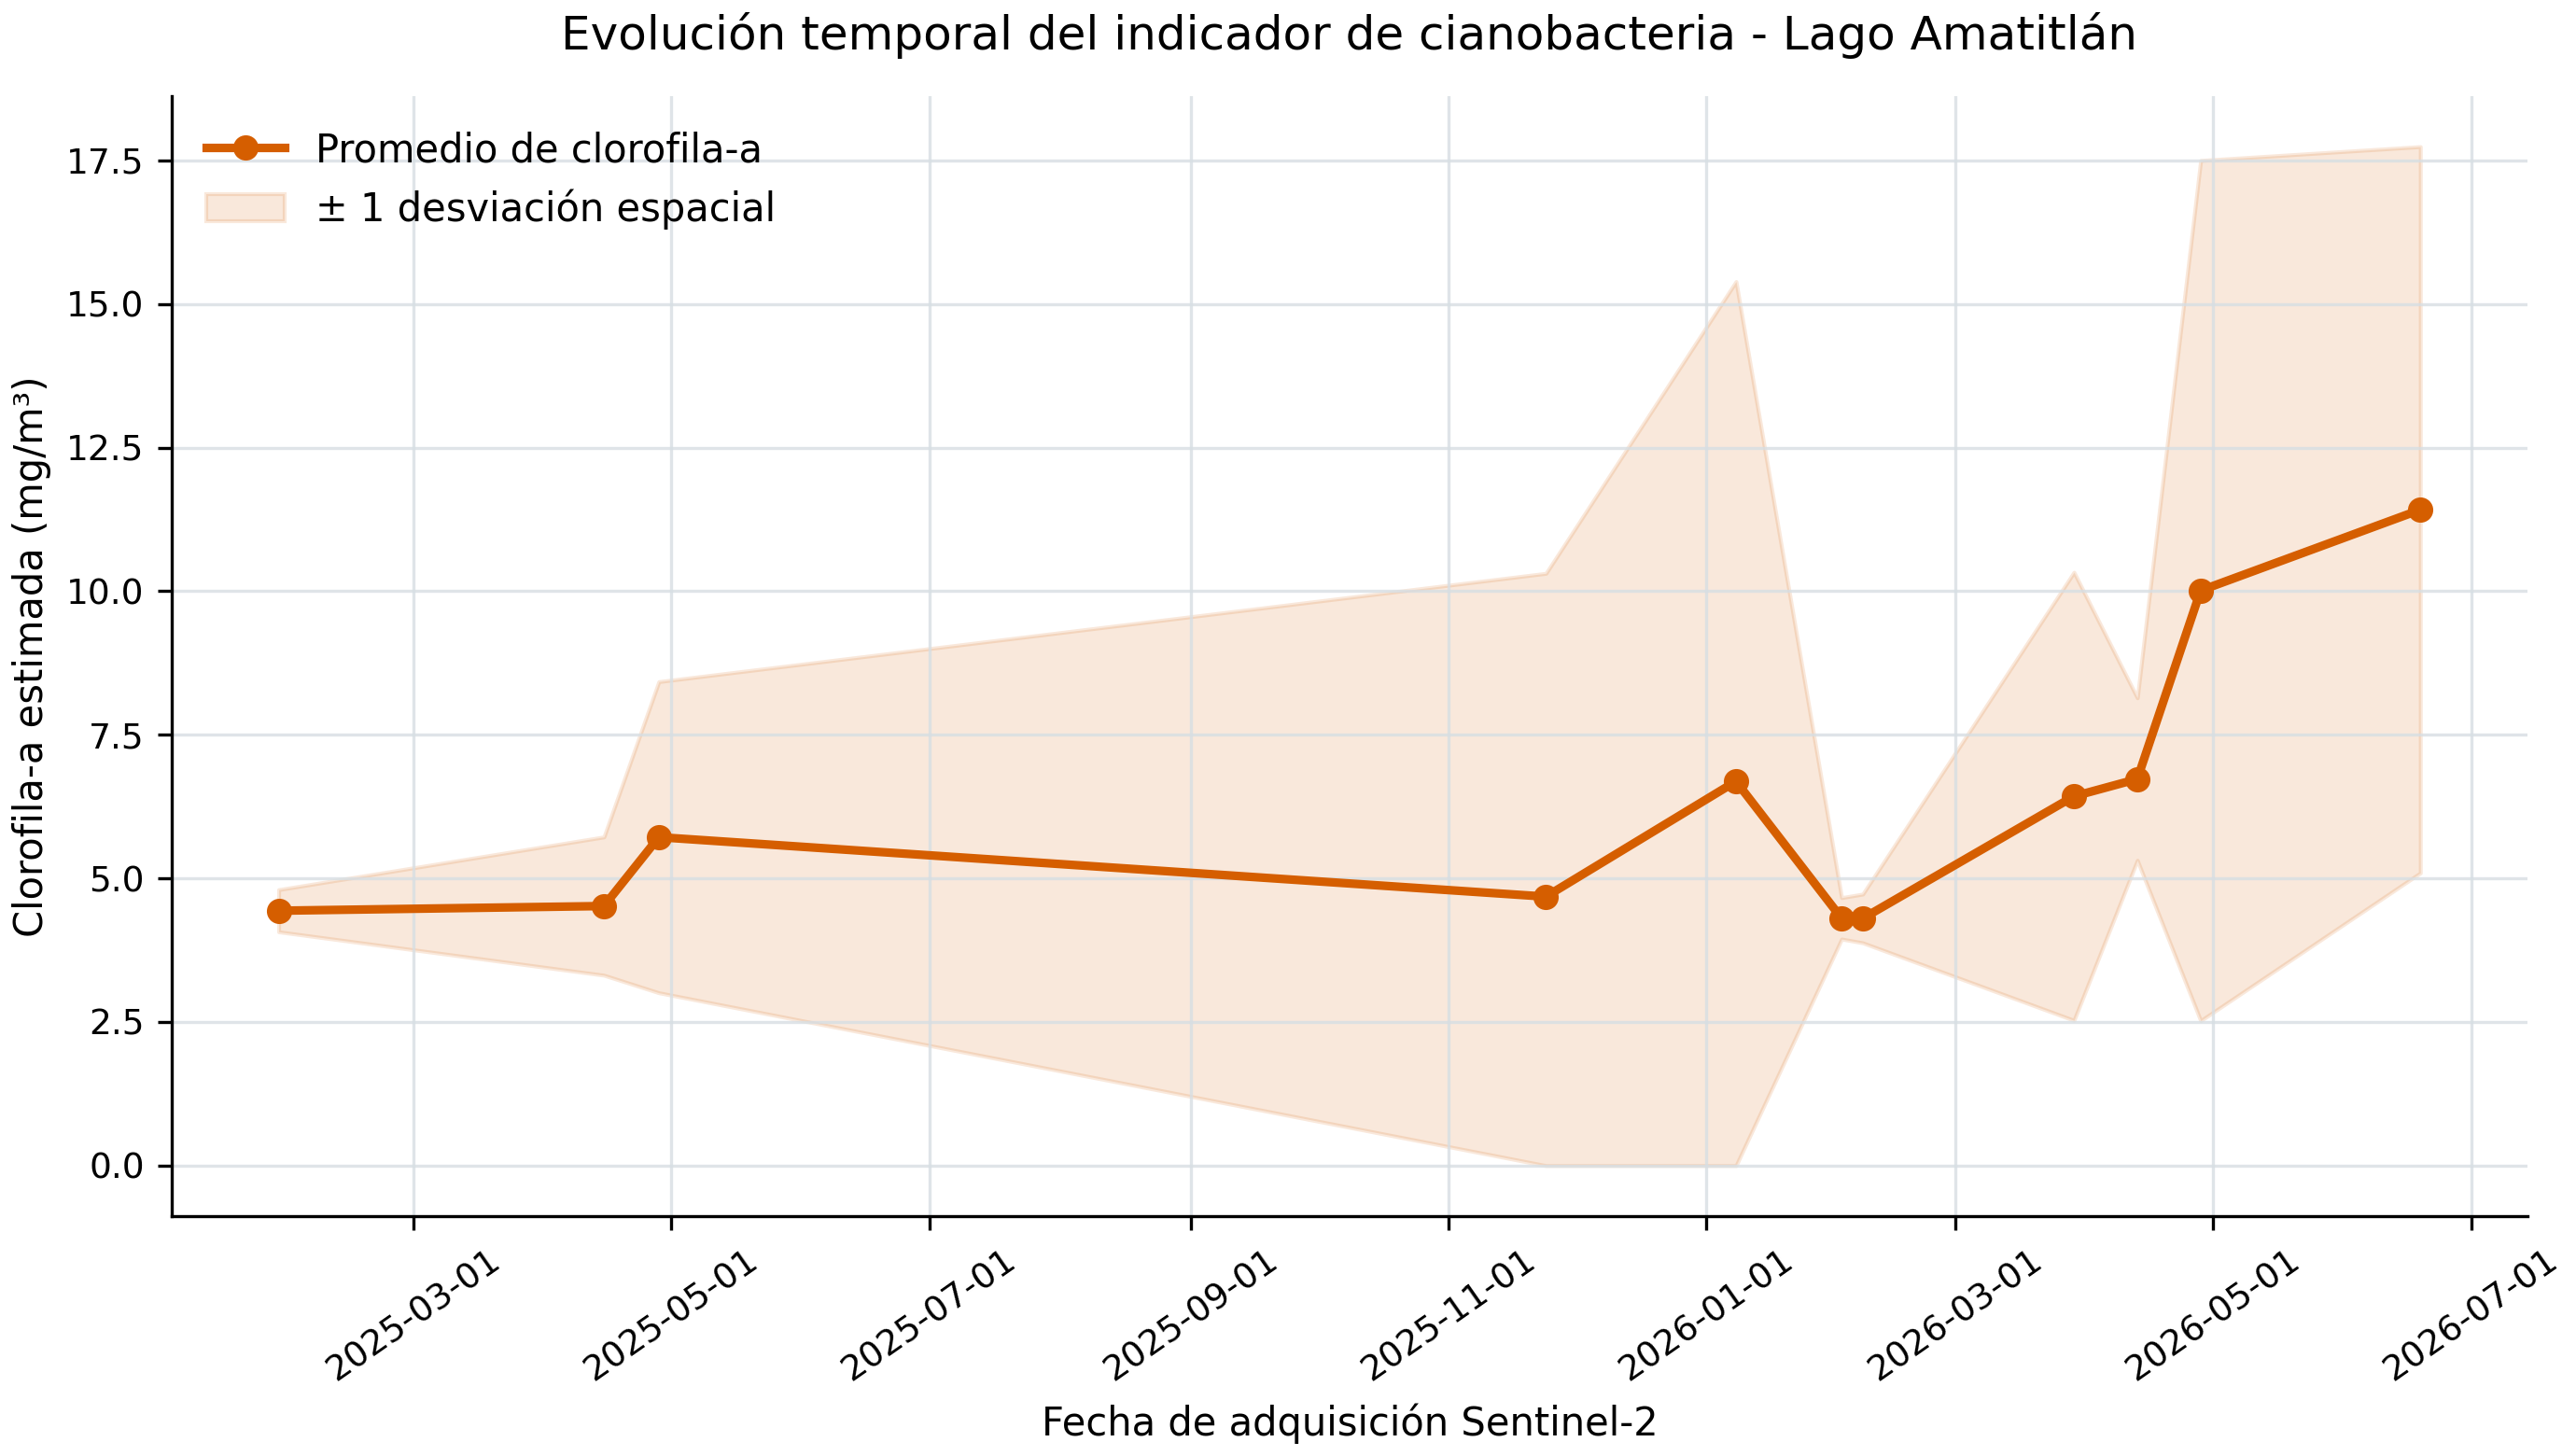

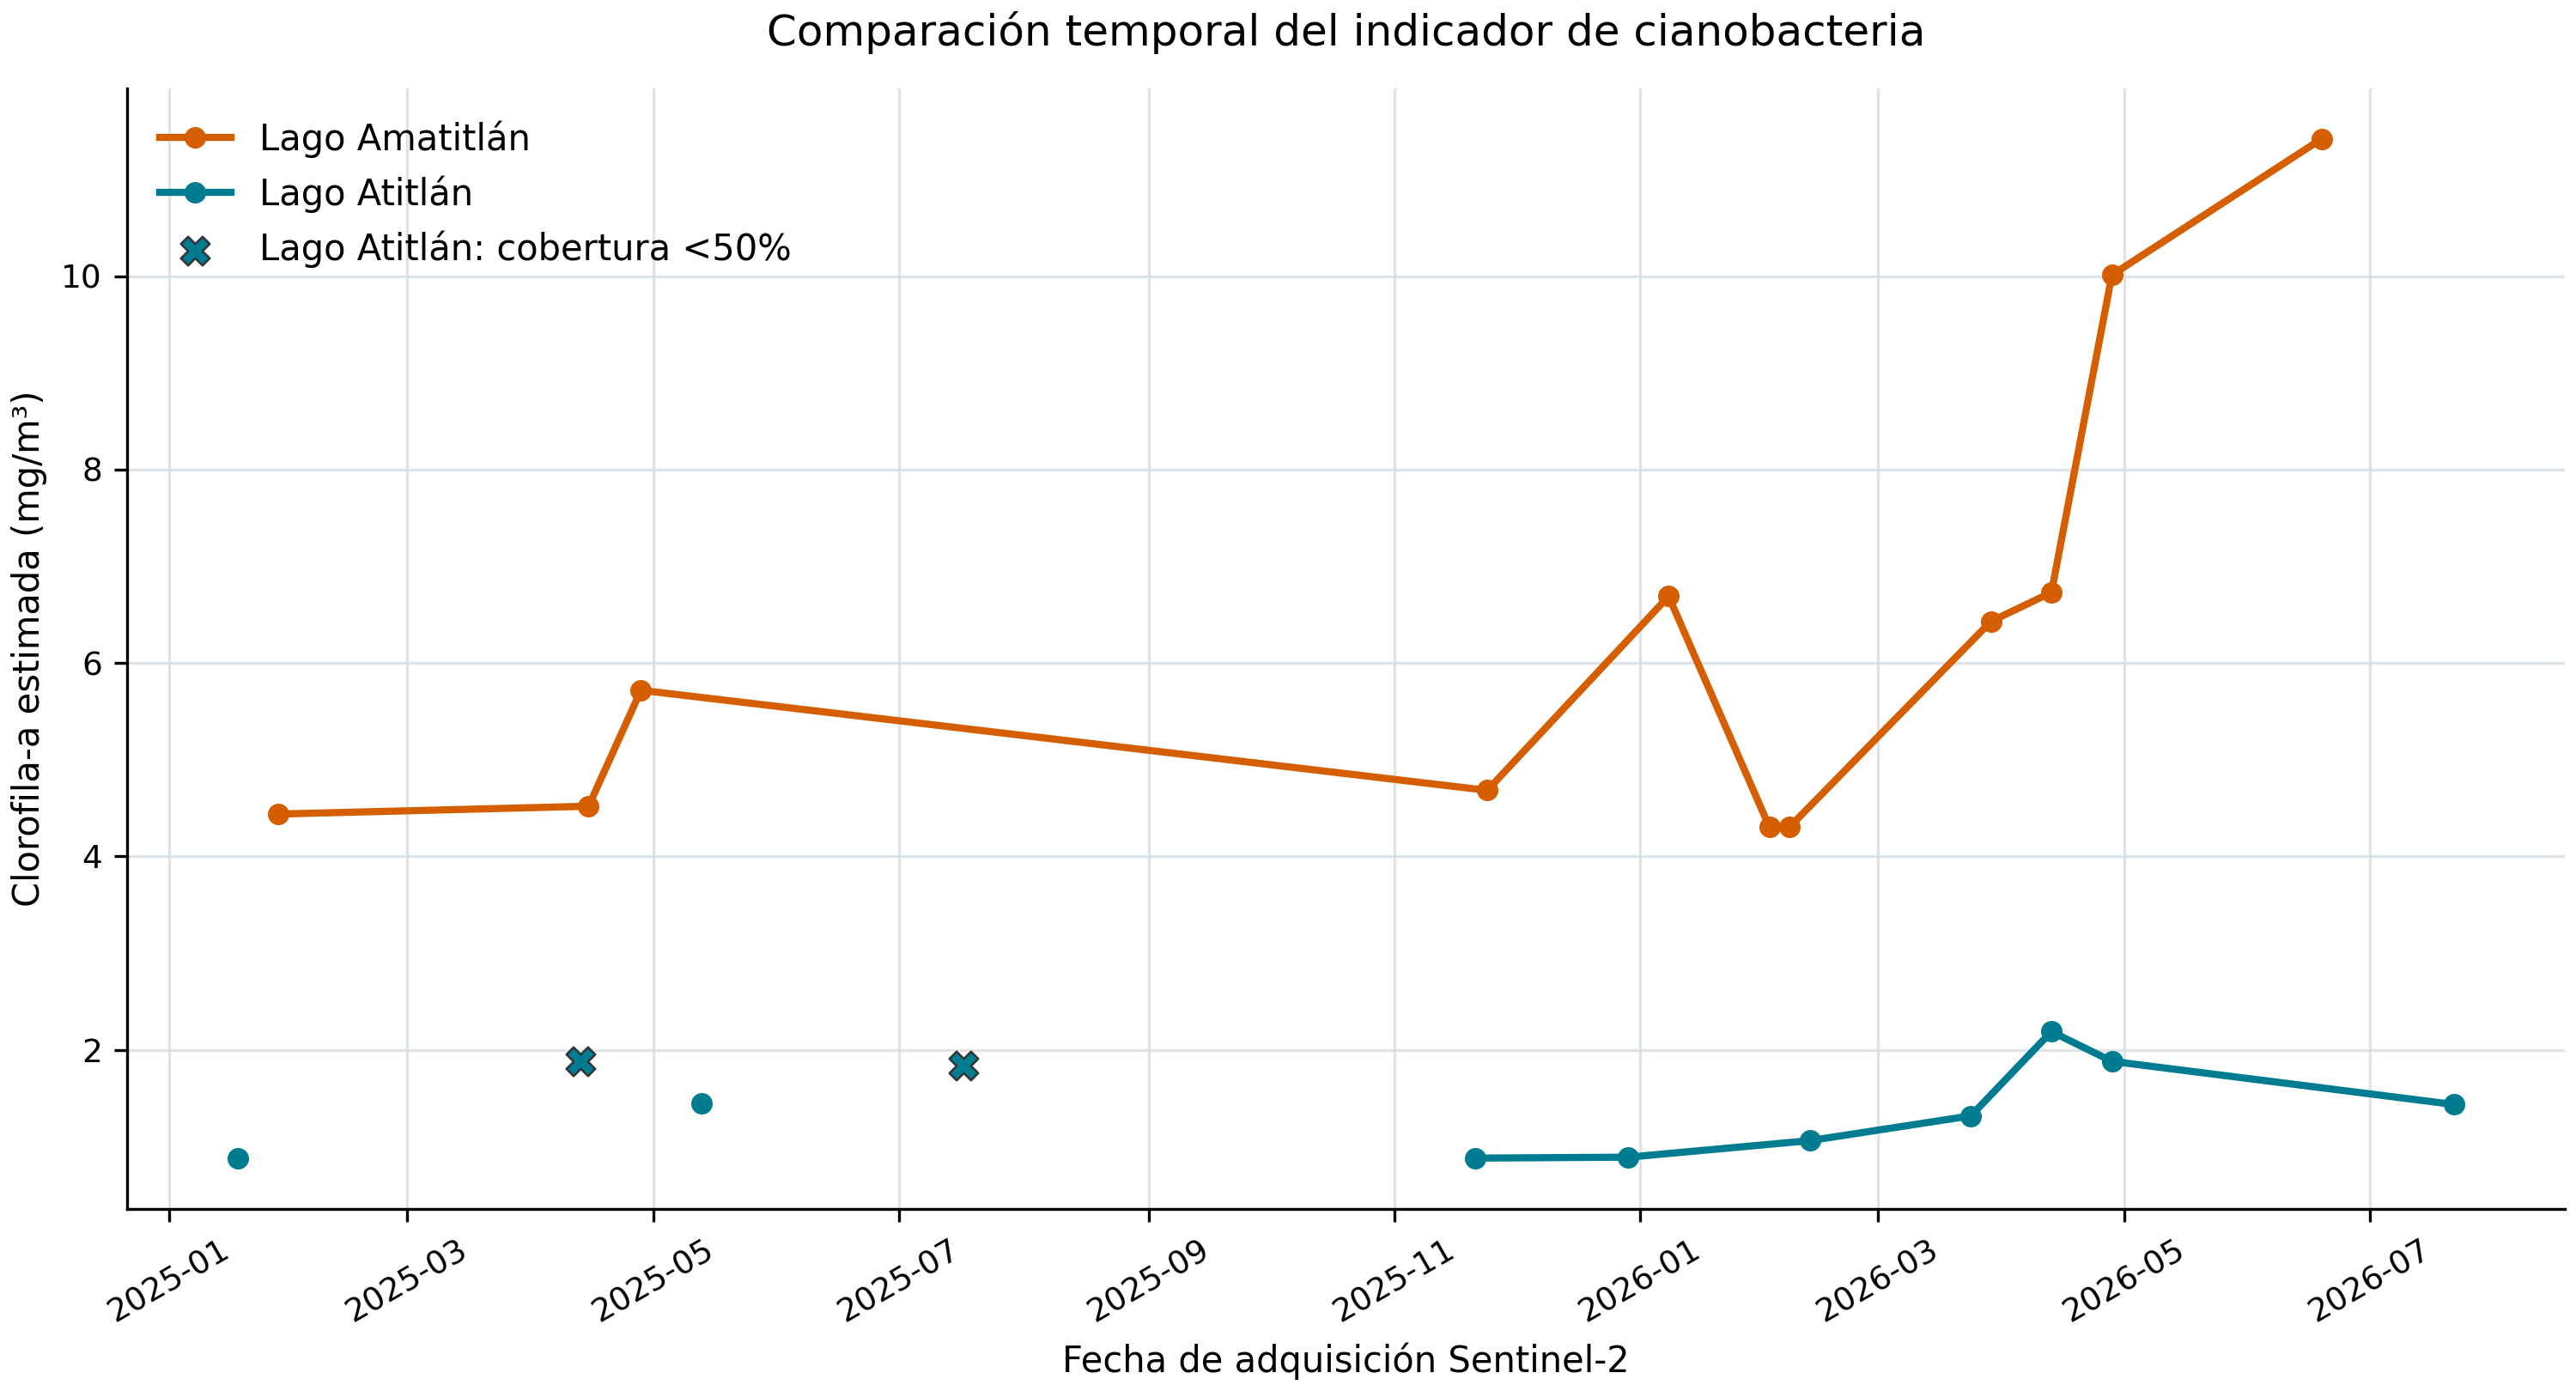

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(4,3))
for ax, lake_key in zip([None, None], []):
    pass
plt.close(fig)

for lake_key in ("atitlan", "amatitlan"):
    display(Image(filename=str(FIGURES_DIR / f"temporal_{lake_key}.png")))
display(Image(filename=str(FIGURES_DIR / "temporal_comparison.png")))

### 4.3 y 4.4 — Picos de floración e interpretación

In [10]:
for lake_key, info in interpretation.items():
    print(f"--- {info['lake']} ---")
    print(f"Patrón: la serie {info['pattern']}")
    print(f"Máximo: {info['maximum_date']} (promedio {info['maximum_mean']:.2f} mg/m3, percentil {info['maximum_percentile_rank']:.0f})")
    print(f"Fechas con pico estadístico (z robusto o Tukey): {info['statistical_peak_dates']}")
    print(f"Fechas de baja cobertura (no comparables): {info['low_coverage_dates']}")
    print(f"Nota: {info['caution']}\n")

--- Lago Amatitlán ---
Patrón: la serie fluctúa, con múltiples cambios entre aumentos y descensos
Máximo: 2026-06-19 (promedio 11.42 mg/m3, percentil 100)
Fechas con pico estadístico (z robusto o Tukey): ['2026-06-19', '2026-04-28']
Fechas de baja cobertura (no comparables): []
Nota: La serie es observacional y el indicador satelital es una estimación. Lluvia, temperatura o nutrientes son hipótesis, no causas probadas aquí.

--- Lago Atitlán ---
Patrón: la serie fluctúa, con múltiples cambios entre aumentos y descensos
Máximo: 2026-04-13 (promedio 2.19 mg/m3, percentil 100)
Fechas con pico estadístico (z robusto o Tukey): []
Fechas de baja cobertura (no comparables): ['2025-04-13', '2025-07-17']
Nota: La serie es observacional y el indicador satelital es una estimación. Lluvia, temperatura o nutrientes son hipótesis, no causas probadas aquí.



**Interpretación (ejercicio 4.4):** en Amatitlán el indicador tiende a
aumentar hacia 2026, con máximos marcados en 2026-04-28 y 2026-06-19
(temporada más cálida/seca del primer semestre). En Atitlán la serie
**fluctúa** sin una tendencia neta clara, con un máximo puntual en
2026-04-13; dos fechas (2025-04-13 y 2025-07-17) tuvieron cobertura fuente
muy baja (<15%) por nubosidad y no deben usarse para afirmar un pico de todo
el lago, solo del sector efectivamente observado ese día.

El informe de avance de este commit ya quedó generado en
`docs/avance_lab4.pdf` (`src/report.py`), dirigido a ambientalistas sin
conocimientos de programación, cubriendo estos primeros 4 ejercicios.

In [11]:
from src.report import build_reports
md_path, pdf_path = build_reports()
print("Informe de avance (ejercicios 1-4):", pdf_path)

Informe de avance (ejercicios 1-4): /home/claude/Lab4DataScience/docs/avance_lab4.pdf


---
### Cierre del commit 1

Con esto quedan resueltos los ejercicios 1 a 4 del enunciado y generado el
avance que se entregó el 13 de agosto. El resto del equipo continúa desde
aquí con el análisis espacial (ejercicio 5) y de correlación (ejercicio 6)
en el siguiente notebook / commit.